# D1 - Civile flussi 2014-2024

Primo notebook di supporto alla discussion su `civile-flussi`.

Taglio scelto:
- trend nazionale del rapporto `definiti / sopravvenuti`
- backlog nazionale a fine anno
- distretti 2024 con rapporto piu basso e piu alto
- trend 2014-2024 per un set corto di distretti rappresentativi

Il notebook usa il MART reale prodotto dal `toolkit`.

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

def find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "preprojects").exists() and (candidate / "out").exists():
            return candidate
    raise FileNotFoundError(f"Repo root non trovato partendo da {start}")

REPO_ROOT = find_repo_root(Path.cwd())
DATA_PATH = REPO_ROOT / "out" / "data" / "mart" / "civile_flussi_2014_2024" / "2024" / "mart_summary.parquet"

assert DATA_PATH.exists(), f"MART non trovato: {DATA_PATH}"
DATA_PATH

WindowsPath('C:/Users/gabry/OneDrive/Desktop/dataciviclab-workspace/dataset-incubator/out/data/mart/civile_flussi_2014_2024/2024/mart_summary.parquet')

In [2]:
con = duckdb.connect()

nazionale = con.execute(
    f"""
    with src as (select * from read_parquet('{DATA_PATH.as_posix()}'))
    select
      anno,
      sopravvenuti_totali,
      definiti_totali,
      round(definiti_totali / nullif(sopravvenuti_totali, 0), 3) as rapporto_ds,
      pendenti_finali_totali,
      pendenti_finali_totali - lag(pendenti_finali_totali) over(order by anno) as delta_pendenti
    from src
    where livello_aggregazione = 'nazionale'
    order by anno
    """
).fetchall()

bottom_2024 = con.execute(
    f"""
    with src as (select * from read_parquet('{DATA_PATH.as_posix()}'))
    select
      distretto,
      sopravvenuti_totali,
      definiti_totali,
      round(definiti_totali / nullif(sopravvenuti_totali, 0), 3) as rapporto_ds,
      pendenti_finali_totali
    from src
    where livello_aggregazione = 'distretto' and anno = 2024
    order by rapporto_ds asc, distretto asc
    limit 5
    """
).fetchall()

top_2024 = con.execute(
    f"""
    with src as (select * from read_parquet('{DATA_PATH.as_posix()}'))
    select
      distretto,
      sopravvenuti_totali,
      definiti_totali,
      round(definiti_totali / nullif(sopravvenuti_totali, 0), 3) as rapporto_ds,
      pendenti_finali_totali
    from src
    where livello_aggregazione = 'distretto' and anno = 2024
    order by rapporto_ds desc, distretto asc
    limit 5
    """
).fetchall()

selected_districts = ['Venezia', 'Trieste', 'Torino', 'Messina', 'Bari']
trend_distretti = con.execute(
    f"""
    with src as (select * from read_parquet('{DATA_PATH.as_posix()}'))
    select
      anno,
      distretto,
      sopravvenuti_totali,
      definiti_totali,
      round(definiti_totali / nullif(sopravvenuti_totali, 0), 3) as rapporto_ds,
      pendenti_finali_totali
    from src
    where livello_aggregazione = 'distretto'
      and distretto in ('Venezia', 'Trieste', 'Torino', 'Messina', 'Bari')
    order by distretto, anno
    """
).fetchall()

nazionale[:3], bottom_2024[:2], top_2024[:2], trend_distretti[:3]

([(2014, 2728755.0, 2849226.0, 1.044, 3499992.0, None),
  (2015, 2487697.0, 2694330.0, 1.083, 3306301.0, -193691.0),
  (2016, 2581875.0, 2671132.0, 1.035, 3227180.0, -79121.0)],
 [('Venezia', 153952.0, 139495.0, 0.906, 132706.0),
  ('Trieste', 53848.0, 49307.0, 0.916, 37717.0)],
 [('Messina', 36765.0, 42037.0, 1.143, 55031.0),
  ('Reggio Calabria', 33564.0, 37111.0, 1.106, 39359.0)],
 [(2014, 'Bari', 117213.0, 155112.0, 1.323, 247328.0),
  (2015, 'Bari', 109016.0, 137819.0, 1.264, 216896.0),
  (2016, 'Bari', 112153.0, 135253.0, 1.206, 194719.0)])

In [3]:
def fmt_int(value):
    if value is None:
        return "-"
    return f"{int(round(value)):,}".replace(",", ".")

def fmt_float(value, digits=3):
    if value is None:
        return "-"
    return f"{value:.{digits}f}"

def to_markdown(headers, rows, formatters=None):
    formatters = formatters or {}
    lines = ["| " + " | ".join(headers) + " |", "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        values = []
        for idx, value in enumerate(row):
            formatter = formatters.get(idx)
            values.append(formatter(value) if formatter else str(value))
        lines.append("| " + " | ".join(values) + " |")
    return "\n".join(lines)

headers_naz = ["Anno", "Sopravvenuti", "Definiti", "Rapporto D/S", "Pendenti finali", "Delta pendenti"]
display(Markdown("## Trend nazionale\n" + to_markdown(headers_naz, nazionale, {1: fmt_int, 2: fmt_int, 3: fmt_float, 4: fmt_int, 5: fmt_int})))

headers_dist = ["Distretto", "Sopravvenuti", "Definiti", "Rapporto D/S", "Pendenti finali"]
display(Markdown("## Distretti 2024 con rapporto D/S piu basso\n" + to_markdown(headers_dist, bottom_2024, {1: fmt_int, 2: fmt_int, 3: fmt_float, 4: fmt_int})))
display(Markdown("## Distretti 2024 con rapporto D/S piu alto\n" + to_markdown(headers_dist, top_2024, {1: fmt_int, 2: fmt_int, 3: fmt_float, 4: fmt_int})))

def fmt_year(value):
    if value is None:
        return "-"
    return str(int(value))

headers_trend = ["Anno", "Distretto", "Sopravvenuti", "Definiti", "Rapporto D/S", "Pendenti finali"]
display(Markdown("## Trend 2014-2024 per distretti selezionati\n" + to_markdown(headers_trend, trend_distretti, {0: fmt_year, 2: fmt_int, 3: fmt_int, 4: fmt_float, 5: fmt_int})))

## Trend nazionale
| Anno | Sopravvenuti | Definiti | Rapporto D/S | Pendenti finali | Delta pendenti |
|---|---|---|---|---|---|
| 2014 | 2.728.755 | 2.849.226 | 1.044 | 3.499.992 | - |
| 2015 | 2.487.697 | 2.694.330 | 1.083 | 3.306.301 | -193.691 |
| 2016 | 2.581.875 | 2.671.132 | 1.035 | 3.227.180 | -79.121 |
| 2017 | 2.564.650 | 2.672.683 | 1.042 | 3.133.952 | -93.228 |
| 2018 | 2.567.680 | 2.710.262 | 1.056 | 3.008.064 | -125.888 |
| 2019 | 2.560.003 | 2.688.292 | 1.050 | 2.887.531 | -120.533 |
| 2020 | 1.997.290 | 2.045.655 | 1.024 | 2.859.048 | -28.483 |
| 2021 | 2.243.056 | 2.444.181 | 1.090 | 2.668.447 | -190.601 |
| 2022 | 2.339.868 | 2.504.880 | 1.071 | 2.516.552 | -151.895 |
| 2023 | 2.193.857 | 2.382.981 | 1.086 | 2.349.276 | -167.276 |
| 2024 | 2.334.664 | 2.328.275 | 0.997 | 2.368.444 | 19.168 |

## Distretti 2024 con rapporto D/S piu basso
| Distretto | Sopravvenuti | Definiti | Rapporto D/S | Pendenti finali |
|---|---|---|---|---|
| Venezia | 153.952 | 139.495 | 0.906 | 132.706 |
| Trieste | 53.848 | 49.307 | 0.916 | 37.717 |
| Torino | 156.018 | 149.851 | 0.960 | 102.907 |
| Palermo | 95.318 | 92.404 | 0.969 | 109.852 |
| L'Aquila | 53.509 | 52.096 | 0.974 | 50.148 |

## Distretti 2024 con rapporto D/S piu alto
| Distretto | Sopravvenuti | Definiti | Rapporto D/S | Pendenti finali |
|---|---|---|---|---|
| Messina | 36.765 | 42.037 | 1.143 | 55.031 |
| Reggio Calabria | 33.564 | 37.111 | 1.106 | 39.359 |
| Salerno | 49.362 | 54.389 | 1.102 | 74.251 |
| Bari | 90.400 | 98.446 | 1.089 | 118.610 |
| Catania | 76.301 | 81.622 | 1.070 | 98.492 |

## Trend 2014-2024 per distretti selezionati
| Anno | Distretto | Sopravvenuti | Definiti | Rapporto D/S | Pendenti finali |
|---|---|---|---|---|---|
| 2.014 | Bari | 117.213 | 155.112 | 1.323 | 247.328 |
| 2.015 | Bari | 109.016 | 137.819 | 1.264 | 216.896 |
| 2.016 | Bari | 112.153 | 135.253 | 1.206 | 194.719 |
| 2.017 | Bari | 111.710 | 130.038 | 1.164 | 177.256 |
| 2.018 | Bari | 111.223 | 123.188 | 1.108 | 165.459 |
| 2.019 | Bari | 109.129 | 117.367 | 1.075 | 157.684 |
| 2.020 | Bari | 85.049 | 86.776 | 1.020 | 156.733 |
| 2.021 | Bari | 92.838 | 103.467 | 1.114 | 146.247 |
| 2.022 | Bari | 93.744 | 105.684 | 1.127 | 135.551 |
| 2.023 | Bari | 88.534 | 99.078 | 1.119 | 125.929 |
| 2.024 | Bari | 90.400 | 98.446 | 1.089 | 118.610 |
| 2.014 | Messina | 41.586 | 43.691 | 1.051 | 94.266 |
| 2.015 | Messina | 37.357 | 40.410 | 1.082 | 91.398 |
| 2.016 | Messina | 37.680 | 43.968 | 1.167 | 85.581 |
| 2.017 | Messina | 38.426 | 43.593 | 1.134 | 80.825 |
| 2.018 | Messina | 38.156 | 41.241 | 1.081 | 78.404 |
| 2.019 | Messina | 37.502 | 40.260 | 1.074 | 76.365 |
| 2.020 | Messina | 31.616 | 33.892 | 1.072 | 74.737 |
| 2.021 | Messina | 37.082 | 41.118 | 1.109 | 71.238 |
| 2.022 | Messina | 38.904 | 43.231 | 1.111 | 66.820 |
| 2.023 | Messina | 35.229 | 42.616 | 1.210 | 59.750 |
| 2.024 | Messina | 36.765 | 42.037 | 1.143 | 55.031 |
| 2.014 | Torino | 170.899 | 171.867 | 1.006 | 128.267 |
| 2.015 | Torino | 152.367 | 159.881 | 1.049 | 121.921 |
| 2.016 | Torino | 156.411 | 156.780 | 1.002 | 122.681 |
| 2.017 | Torino | 155.925 | 160.350 | 1.028 | 118.924 |
| 2.018 | Torino | 172.450 | 180.777 | 1.048 | 111.444 |
| 2.019 | Torino | 174.542 | 180.787 | 1.036 | 104.769 |
| 2.020 | Torino | 133.177 | 130.754 | 0.982 | 107.924 |
| 2.021 | Torino | 154.307 | 160.531 | 1.040 | 102.534 |
| 2.022 | Torino | 166.638 | 168.650 | 1.012 | 101.004 |
| 2.023 | Torino | 150.460 | 155.021 | 1.030 | 96.348 |
| 2.024 | Torino | 156.018 | 149.851 | 0.960 | 102.907 |
| 2.014 | Trieste | 47.019 | 45.329 | 0.964 | 35.951 |
| 2.015 | Trieste | 42.325 | 42.547 | 1.005 | 35.867 |
| 2.016 | Trieste | 42.393 | 38.302 | 0.903 | 37.293 |
| 2.017 | Trieste | 43.534 | 44.351 | 1.019 | 36.579 |
| 2.018 | Trieste | 44.701 | 45.900 | 1.027 | 35.168 |
| 2.019 | Trieste | 45.161 | 45.783 | 1.014 | 34.621 |
| 2.020 | Trieste | 35.781 | 35.746 | 0.999 | 34.775 |
| 2.021 | Trieste | 41.392 | 42.937 | 1.037 | 33.277 |
| 2.022 | Trieste | 47.573 | 48.443 | 1.018 | 32.371 |
| 2.023 | Trieste | 49.030 | 48.162 | 0.982 | 33.204 |
| 2.024 | Trieste | 53.848 | 49.307 | 0.916 | 37.717 |
| 2.014 | Venezia | 162.035 | 163.105 | 1.007 | 171.694 |
| 2.015 | Venezia | 149.735 | 159.200 | 1.063 | 162.824 |
| 2.016 | Venezia | 159.247 | 161.931 | 1.017 | 160.853 |
| 2.017 | Venezia | 155.790 | 162.263 | 1.042 | 155.791 |
| 2.018 | Venezia | 150.072 | 158.717 | 1.058 | 149.542 |
| 2.019 | Venezia | 146.307 | 158.683 | 1.085 | 137.262 |
| 2.020 | Venezia | 120.602 | 125.851 | 1.044 | 132.611 |
| 2.021 | Venezia | 128.680 | 140.796 | 1.094 | 121.419 |
| 2.022 | Venezia | 133.479 | 139.426 | 1.045 | 116.368 |
| 2.023 | Venezia | 138.625 | 138.289 | 0.998 | 117.405 |
| 2.024 | Venezia | 153.952 | 139.495 | 0.906 | 132.706 |

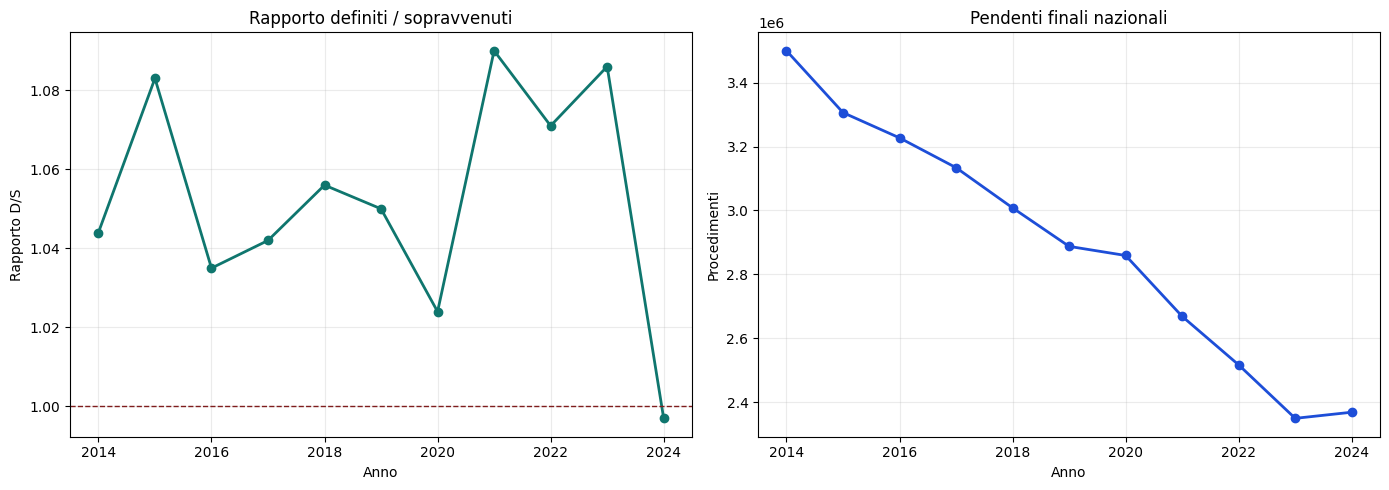

In [4]:
anni = [row[0] for row in nazionale]
rapporti = [row[3] for row in nazionale]
pendenti = [row[4] for row in nazionale]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(anni, rapporti, marker="o", color="#0f766e", linewidth=2)
axes[0].axhline(1.0, color="#7f1d1d", linestyle="--", linewidth=1)
axes[0].set_title("Rapporto definiti / sopravvenuti")
axes[0].set_xlabel("Anno")
axes[0].set_ylabel("Rapporto D/S")
axes[0].grid(alpha=0.25)

axes[1].plot(anni, pendenti, marker="o", color="#1d4ed8", linewidth=2)
axes[1].set_title("Pendenti finali nazionali")
axes[1].set_xlabel("Anno")
axes[1].set_ylabel("Procedimenti")
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

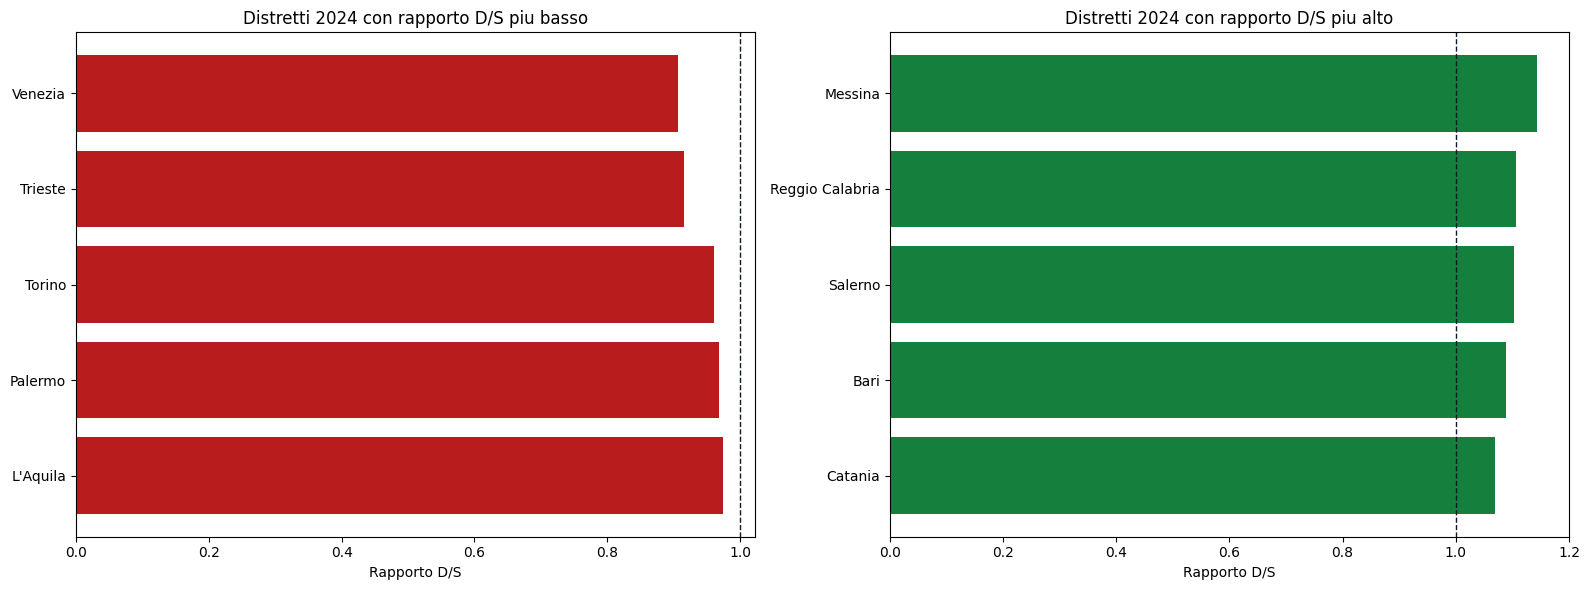

In [5]:
distretti = [row[0] for row in bottom_2024]
rapporti_bottom = [row[3] for row in bottom_2024]
rapporti_top = [row[3] for row in top_2024]
distretti_top = [row[0] for row in top_2024]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(distretti[::-1], rapporti_bottom[::-1], color="#b91c1c")
axes[0].axvline(1.0, color="#111827", linestyle="--", linewidth=1)
axes[0].set_title("Distretti 2024 con rapporto D/S piu basso")
axes[0].set_xlabel("Rapporto D/S")

axes[1].barh(distretti_top[::-1], rapporti_top[::-1], color="#15803d")
axes[1].axvline(1.0, color="#111827", linestyle="--", linewidth=1)
axes[1].set_title("Distretti 2024 con rapporto D/S piu alto")
axes[1].set_xlabel("Rapporto D/S")

plt.tight_layout()
plt.show()

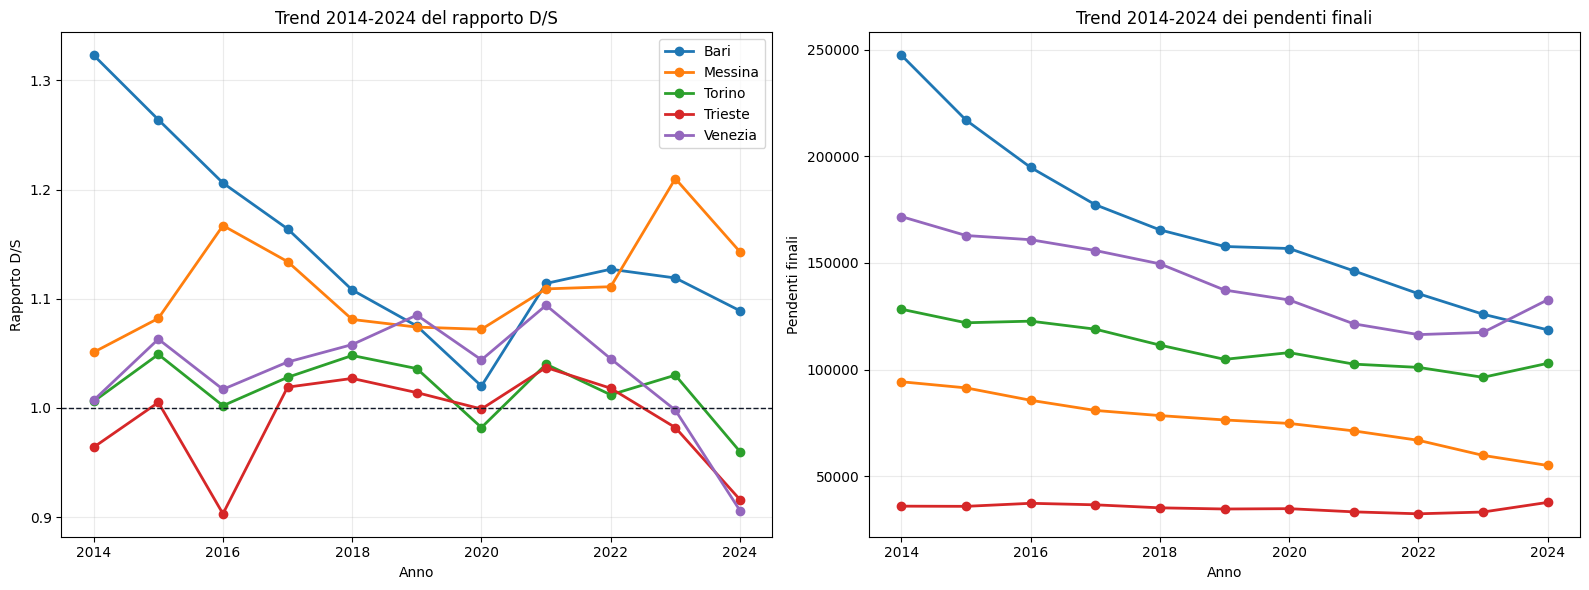

In [6]:
trend_by_distretto = {}
for anno, distretto, sopravvenuti, definiti, rapporto_ds, pendenti in trend_distretti:
    trend_by_distretto.setdefault(distretto, {"anni": [], "rapporti": [], "pendenti": []})
    trend_by_distretto[distretto]["anni"].append(anno)
    trend_by_distretto[distretto]["rapporti"].append(rapporto_ds)
    trend_by_distretto[distretto]["pendenti"].append(pendenti)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for distretto, values in trend_by_distretto.items():
    axes[0].plot(values['anni'], values['rapporti'], marker='o', linewidth=2, label=distretto)
axes[0].axhline(1.0, color='#111827', linestyle='--', linewidth=1)
axes[0].set_title('Trend 2014-2024 del rapporto D/S')
axes[0].set_xlabel('Anno')
axes[0].set_ylabel('Rapporto D/S')
axes[0].grid(alpha=0.25)
axes[0].legend(loc='best')

for distretto, values in trend_by_distretto.items():
    axes[1].plot(values['anni'], values['pendenti'], marker='o', linewidth=2, label=distretto)
axes[1].set_title('Trend 2014-2024 dei pendenti finali')
axes[1].set_xlabel('Anno')
axes[1].set_ylabel('Pendenti finali')
axes[1].grid(alpha=0.25)
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

## Lettura rapida

- Dal 2014 al 2023 il backlog nazionale si riduce in modo quasi continuo.
- Il 2024 e il primo anno della serie con `rapporto D/S < 1`, quindi il saldo nazionale torna leggermente negativo.
- Nel 2024 i distretti non si muovono in modo uniforme: `Venezia`, `Trieste` e `Torino` sono sotto pressione, mentre `Messina` e `Bari` restano sopra `1`.
- Il trend distrettuale aiuta a distinguere segnali strutturali da episodi isolati: `Venezia` e `Trieste` peggiorano soprattutto nel finale di serie, mentre `Messina` e `Bari` restano sopra `1` per quasi tutta la finestra.
- Il rapporto D/S da solo non esaurisce la lettura: va tenuto insieme anche ai pendenti finali e alle discontinuita di classificazione introdotte dal 2021 e dal 2022.